# 🧫 Gray-Scott Reaction-Diffusion
### How leopards got their spots — from pure mathematics

`Turing Instability` · `Activator-Inhibitor` · `Morphogenesis` · `PDE Simulation`

---

## What Is Actually Happening?

### The Setup

A flat surface is coated in two invisible chemicals: **U** (prey) and **V** (predator). Both spread outward like ink in water, but V diffuses *slower* than U. Two reactions happen simultaneously:

```
U + 2V → 3V        (V converts U into more V — predator devours prey)
V → P              (V decays spontaneously — predator dies)
```

No biology. No randomness. No hand-drawn pattern. Just two chemicals obeying physics.

### The Equations

These rules encode into two coupled **partial differential equations**:

```
∂U/∂t = Dᵤ∇²U − UV² + f(1 − U)
∂V/∂t = Dᵥ∇²V + UV² − (f + k)V
```

- **∇² (Laplacian)** — the mathematical engine of diffusion; measures how different each point is from its neighbours
- **UV²** — the autocatalytic reaction term; requires one U and two V molecules to collide, making growth nonlinear

### Why Patterns Form — Turing Instability

In 1952, Alan Turing proved: if an activator spreads *slower* than its inhibitor, a tiny random fluctuation will **amplify rather than smooth out**. A local excess of V grows faster than U can diffuse in to suppress it. The uniform state spontaneously collapses into peaks and troughs.

This is **Turing instability** — the mathematical mechanism behind:
- Leopard spots and cheetah stripes
- Zebrafish pigmentation
- Fingerprint whorls
- Coral branching geometry
- Hair follicle spacing

Biology did not design these patterns. The equations did.

> **Key parameters:** `f` = feed rate (how fast U is replenished) · `k` = kill rate (how fast V decays). These two numbers control everything about the final morphology.

---

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from IPython.display import HTML, display
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#03020a',
    'axes.facecolor':    '#03020a',
    'axes.edgecolor':    '#1a0a30',
    'text.color':        '#c8b8ff',
    'axes.labelcolor':   '#c8b8ff',
    'xtick.color':       '#5030a0',
    'ytick.color':       '#5030a0',
    'font.family':       'monospace',
})
print("Ready.")

Ready.


Running Gray-Scott (8,000 steps) ... done.


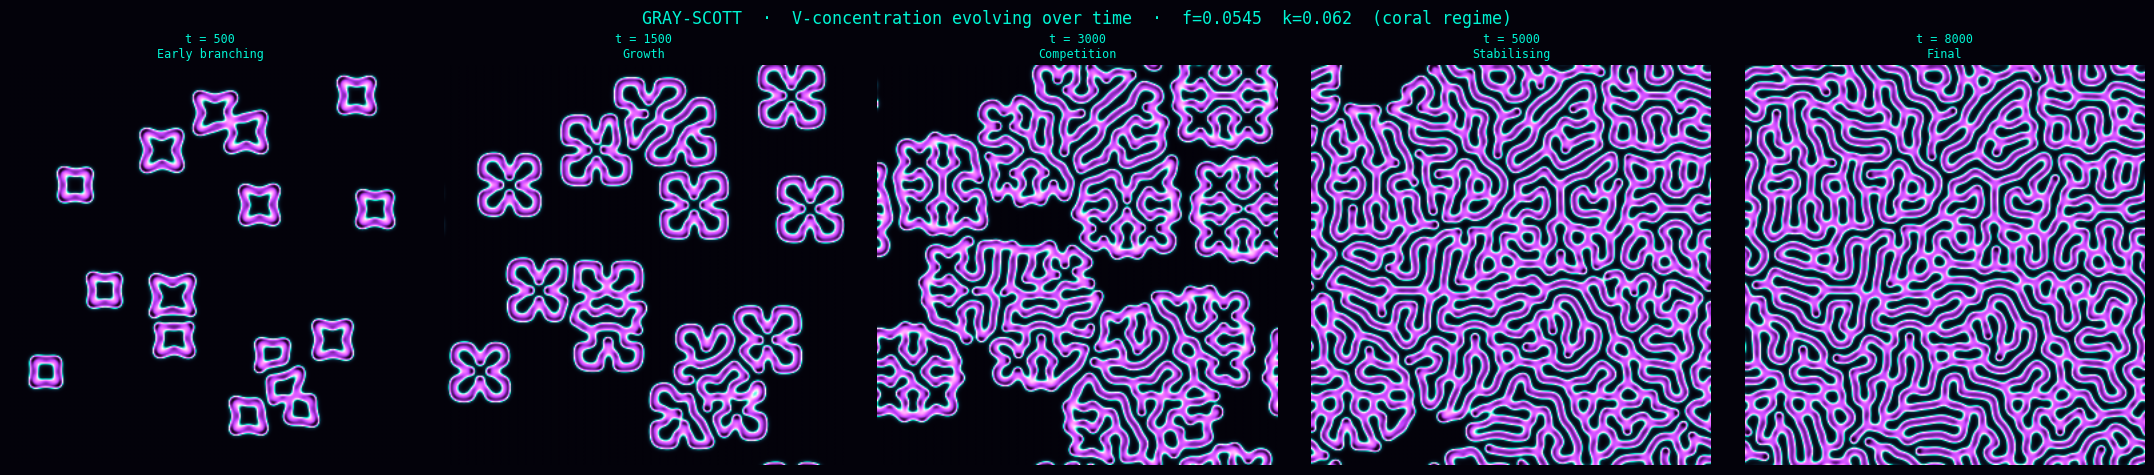

In [5]:
np.random.seed(42)
GRID, STEPS, Du, Dv = 300, 8000, 0.16, 0.08
f, k = 0.0545, 0.062   # coral / branching regime

U = np.ones((GRID, GRID))
V = np.zeros((GRID, GRID))

# Seed random perturbation patches to kick off Turing instability
for _ in range(18):
    cx, cy, r = (np.random.randint(20, GRID-20),
                 np.random.randint(20, GRID-20),
                 np.random.randint(6, 14))
    U[cy-r:cy+r, cx-r:cx+r] = 0.50 + 0.02 * np.random.randn(2*r, 2*r)
    V[cy-r:cy+r, cx-r:cx+r] = 0.25 + 0.01 * np.random.randn(2*r, 2*r)

def lap(X):
    # 5-point stencil Laplacian with periodic boundary conditions
    return (np.roll(X,1,0) + np.roll(X,-1,0) +
            np.roll(X,1,1) + np.roll(X,-1,1) - 4*X)

print("Running Gray-Scott (8,000 steps) ...", end=" ")
snaps = []
for step in range(STEPS):
    uvv = U * V * V
    U += Du * lap(U) - uvv + f * (1 - U)
    V += Dv * lap(V) + uvv - (f + k) * V
    U, V = np.clip(U, 0, 1), np.clip(V, 0, 1)
    if step in (500, 1500, 3000, 5000, STEPS-1):
        snaps.append(V.copy())
print("done.")

cgs = LinearSegmentedColormap.from_list("gs",
    ["#03020a","#0a1a2a","#003344","#00f5d4","#fff","#ff80ff","#c040ff","#1a0020"])

# ── Evolution timeline ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5), facecolor='#03020a')
fig.subplots_adjust(left=.01, right=.99, top=.86, bottom=.06, wspace=.03)
labels = ["t = 500\nEarly branching", "t = 1500\nGrowth",
          "t = 3000\nCompetition", "t = 5000\nStabilising", "t = 8000\nFinal"]
for ax, s, lb in zip(axes, snaps, labels):
    ax.imshow(s, cmap=cgs, vmin=0, vmax=.4, interpolation='bilinear', origin='lower')
    ax.set_title(lb, color='#00f5d4', fontsize=8.5, pad=5)
    ax.axis('off')
fig.suptitle("GRAY-SCOTT  ·  V-concentration evolving over time  ·  f=0.0545  k=0.062  (coral regime)",
             color='#00f5d4', fontsize=12, y=.97)
plt.show()

---
## Parameter Space Tour

The same two equations produce completely different morphologies when `f` and `k` change.

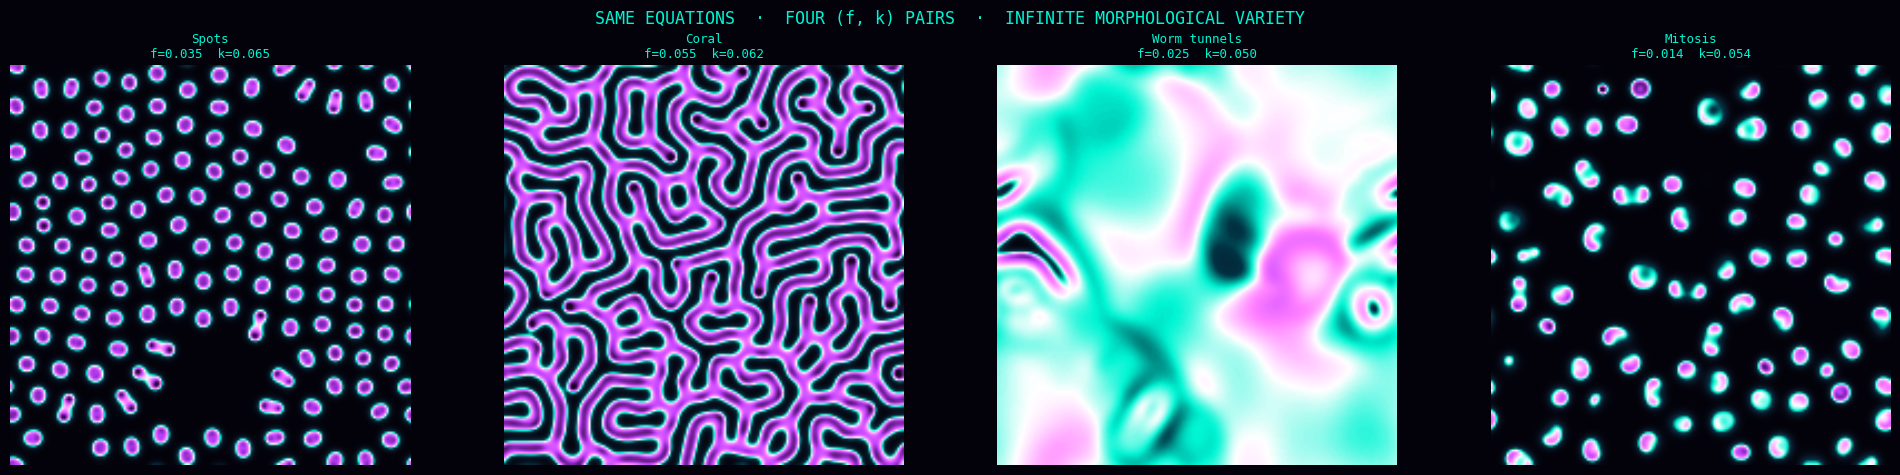

Every pattern above is identical physics. Only f and k changed.


In [6]:
# Same equations — four different (f, k) pairs
configs = [
    (0.035, 0.065, "Spots\nf=0.035  k=0.065"),
    (0.055, 0.062, "Coral\nf=0.055  k=0.062"),
    (0.025, 0.050, "Worm tunnels\nf=0.025  k=0.050"),
    (0.014, 0.054, "Mitosis\nf=0.014  k=0.054"),
]
fig2, ax2 = plt.subplots(1, 4, figsize=(20, 5), facecolor='#03020a')
fig2.subplots_adjust(left=.01, right=.99, top=.86, bottom=.06, wspace=.03)

for ax, (fi, ki, lb) in zip(ax2, configs):
    Ul = np.ones((180, 180));  Vl = np.zeros((180, 180))
    for _ in range(12):
        cx2, cy2 = np.random.randint(15,165), np.random.randint(15,165)
        Ul[cy2-8:cy2+8, cx2-8:cx2+8] = 0.5
        Vl[cy2-8:cy2+8, cx2-8:cx2+8] = 0.25
    for _ in range(6000):
        uvv2 = Ul * Vl * Vl
        Ul += Du*lap(Ul) - uvv2 + fi*(1-Ul)
        Vl += Dv*lap(Vl) + uvv2 - (fi+ki)*Vl
        Ul, Vl = np.clip(Ul,0,1), np.clip(Vl,0,1)
    ax.imshow(Vl, cmap=cgs, vmin=0, vmax=.4, interpolation='bilinear', origin='lower')
    ax.set_title(lb, color='#00f5d4', fontsize=9, pad=5)
    ax.axis('off')

fig2.suptitle("SAME EQUATIONS  ·  FOUR (f, k) PAIRS  ·  INFINITE MORPHOLOGICAL VARIETY",
              color='#00f5d4', fontsize=12, y=.97)
plt.show()
print("Every pattern above is identical physics. Only f and k changed.")